# Retrieval Evaluation Analysis

This notebook processes a JSONL file containing graded retrieval results.

**Goals:**
1. For each query, check whether the **gold document** (identified by `file_name`) was retrieved and whether it was labelled `relevant`.
2. Compare **relevance labels** across the two models present in `botname` to measure divergence.

In [1]:

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid')

## 1. Load the JSONL file

In [ ]:
from pathlib import Path
import json

JSONL_DIR = Path("outputs/results_split")

records = []

for jsonl_file in sorted(JSONL_DIR.glob("results_part_*.jsonl")):
    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))

print(f"Loaded {len(records)} records")
print("\nSample keys:", list(records[0].keys()))

Loaded 10926 records

Sample keys: ['task_id', 'dataset', 'file_name', 'query', 'botname', 'graded_docs']


## 2. Parse records into a flat DataFrame

In [3]:
rows = []
for rec in records:
    task_id   = rec['task_id']
    query     = rec['query']
    gold_file = rec['file_name']
    botname   = rec['botname']
    dataset   = rec['dataset']

    for doc in rec['graded_docs']:
        rows.append({
            'task_id':             task_id,
            'query':               query,
            'gold_file':           gold_file,
            'botname':             botname,
            'dataset':             dataset,
            'doc_id':              doc['id'],
            'doc_file':            doc['file_name'],
            'mmr_score':           doc.get('MMR_score'),
            'cross_encoder_score': doc.get('cross_encoder_score'),
            'relevance':           doc.get('relevance'),
            'is_gold':             doc['file_name'] == gold_file,
        })


df = pd.DataFrame(rows)
df['query_key'] = df['dataset'] + '||' + df['gold_file']

bots = df['botname'].unique()
label_map = {b: b.split('/')[-1] for b in bots}
df['model'] = df['botname'].map(label_map)

gold_df = df[df['is_gold']].copy()

print(df.shape)
df.head()

(109260, 13)


,task_id,query,gold_file,botname,dataset,doc_id,doc_file,mmr_score,cross_encoder_score,relevance,is_gold,query_key,model
0,Approf_Accesso all’Ospedale per il parto.txt||3EAs/User Design Persona-1.2-0...,"Ostetrica, cosa devo portare con me il giorno del ricovero programmato?",Approf_Accesso all’Ospedale per il parto.txt,3EAs/User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501,ensemble__nomic-chatfaq__FULL,2d4f0f21-c552-4df5-b9d9-f2639dba2113,Approf_Accesso all’Ospedale per il parto.txt,NaN,1.457084,relevant,True,ensemble__nomic-chatfaq__FULL||Approf_Accesso all’Ospedale per il parto.txt,User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501
1,Approf_Accesso all’Ospedale per il parto.txt||3EAs/User Design Persona-1.2-0...,"Ostetrica, cosa devo portare con me il giorno del ricovero programmato?",Approf_Accesso all’Ospedale per il parto.txt,3EAs/User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501,ensemble__nomic-chatfaq__FULL,426c9d8c-8f1b-41d0-b76d-b7998551f65b,Approf_Accesso all’Ospedale per il parto.txt,NaN,0.935922,relevant,True,ensemble__nomic-chatfaq__FULL||Approf_Accesso all’Ospedale per il parto.txt,User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501
2,Approf_Accesso all’Ospedale per il parto.txt||3EAs/User Design Persona-1.2-0...,"Ostetrica, cosa devo portare con me il giorno del ricovero programmato?",Approf_Accesso all’Ospedale per il parto.txt,3EAs/User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501,ensemble__nomic-chatfaq__FULL,b29601ed-ae33-4da5-ab7b-b5cce8ae0b31,Uppa_738.txt,NaN,0.342060,relevant,False,ensemble__nomic-chatfaq__FULL||Approf_Accesso all’Ospedale per il parto.txt,User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501
3,Approf_Accesso all’Ospedale per il parto.txt||3EAs/User Design Persona-1.2-0...,"Ostetrica, cosa devo portare con me il giorno del ricovero programmato?",Approf_Accesso all’Ospedale per il parto.txt,3EAs/User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501,ensemble__nomic-chatfaq__FULL,3bc3cd27-c627-4190-afb4-55f0825eca21,Uppa_645.txt,NaN,0.210136,not relevant,False,ensemble__nomic-chatfaq__FULL||Approf_Accesso all’Ospedale per il parto.txt,User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501
4,Approf_Accesso all’Ospedale per il parto.txt||3EAs/User Design Persona-1.2-0...,"Ostetrica, cosa devo portare con me il giorno del ricovero programmato?",Approf_Accesso all’Ospedale per il parto.txt,3EAs/User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501,ensemble__nomic-chatfaq__FULL,c6035a3d-50db-4b83-9fc6-e793d65fd878,Approf_Accesso all’Ospedale per il parto.txt,NaN,-0.122910,not relevant,True,ensemble__nomic-chatfaq__FULL||Approf_Accesso all’Ospedale per il parto.txt,User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501


## 3. Gold-document retrieval & relevance check

For each `(task_id, botname)` pair we check:
- Was the gold document **present** in the retrieved list?
- If present, was it labelled **relevant**?

In [4]:
gold_df = df[df['is_gold']].copy()
gold_df['is_relevant'] = gold_df['relevance'] == 'relevant'

# One row per (task_id, botname)
gold_summary = gold_df[['task_id', 'query', 'gold_file', 'botname',
                          'mmr_score', 'cross_encoder_score', 'relevance', 'is_relevant']]

print('Gold doc retrieved in N queries:', len(gold_summary))
print('\nRelevance breakdown:')
print(gold_summary['relevance'].value_counts())
gold_summary

Gold doc retrieved in N queries: 25030

Relevance breakdown:
relevance
relevant        20226
not relevant     4804
Name: count, dtype: int64


,task_id,query,gold_file,botname,mmr_score,cross_encoder_score,relevance,is_relevant
0,Approf_Accesso all’Ospedale per il parto.txt||3EAs/User Design Persona-1.2-0...,"Ostetrica, cosa devo portare con me il giorno del ricovero programmato?",Approf_Accesso all’Ospedale per il parto.txt,3EAs/User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501,NaN,1.457084,relevant,True
1,Approf_Accesso all’Ospedale per il parto.txt||3EAs/User Design Persona-1.2-0...,"Ostetrica, cosa devo portare con me il giorno del ricovero programmato?",Approf_Accesso all’Ospedale per il parto.txt,3EAs/User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501,NaN,0.935922,relevant,True
4,Approf_Accesso all’Ospedale per il parto.txt||3EAs/User Design Persona-1.2-0...,"Ostetrica, cosa devo portare con me il giorno del ricovero programmato?",Approf_Accesso all’Ospedale per il parto.txt,3EAs/User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501,NaN,-0.122910,not relevant,False
10,Approf_Accesso all’Ospedale per il parto.txt||3EAs/User Design Persona-1.2-0...,"Ostetrica, cosa devo portare con me il giorno del ricovero programmato?",Approf_Accesso all’Ospedale per il parto.txt,3EAs/User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct,NaN,1.457084,relevant,True
11,Approf_Accesso all’Ospedale per il parto.txt||3EAs/User Design Persona-1.2-0...,"Ostetrica, cosa devo portare con me il giorno del ricovero programmato?",Approf_Accesso all’Ospedale per il parto.txt,3EAs/User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct,NaN,0.935922,relevant,True
...,...,...,...,...,...,...,...,...
109243,mmr__nomic-chatfaq__FULL||ISS_254.txt||3EAs/User Design Persona-1.2-0.9-1-ll...,Qual è la percentuale di donne che donano un rene al proprio marito in casi ...,ISS_254.txt,3EAs/User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct,0.488519,-0.999863,not relevant,False
109247,mmr__nomic-chatfaq__FULL||ISS_254.txt||3EAs/User Design Persona-1.2-0.9-1-ll...,Qual è la percentuale di donne che donano un rene al proprio marito in casi ...,ISS_254.txt,3EAs/User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct,0.434086,-1.778463,not relevant,False
109250,mmr__nomic-chatfaq__FULL||Uppa_844.txt||3EAs/User Design Persona-1.2-0.9-1-l...,"Ostetrica, quali sono le sostanze che vengono dosate nel bitest?",Uppa_844.txt,3EAs/User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct,0.611834,0.496888,relevant,True
109251,mmr__nomic-chatfaq__FULL||Uppa_844.txt||3EAs/User Design Persona-1.2-0.9-1-l...,"Ostetrica, quali sono le sostanze che vengono dosate nel bitest?",Uppa_844.txt,3EAs/User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct,0.533137,-0.137726,relevant,True


In [5]:
import warnings 

gold_df = df[df['is_gold']].copy()
gold_retrieved_per_query = (df.groupby('query_key')['is_gold']
    .any()
    .reset_index()
    .rename(columns={'is_gold': 'gold_retrieved'}))

retrieval_rate = gold_retrieved_per_query['gold_retrieved'].mean()
n_retrieved = gold_retrieved_per_query['gold_retrieved'].sum()
n_total = len(gold_retrieved_per_query)
print(f"Retriever recall@10: {retrieval_rate:.1%} ({n_retrieved}/{n_total} queries contain the gold doc)")

# Verify both models saw exactly the same queries
queries_per_model = df.groupby('model')['query_key'].nunique()
print(f"\nQueries per model:")
print(queries_per_model.to_string())
try:
    assert queries_per_model.nunique() == 1, "⚠️ Models saw different queries!"
    print("✓ Both models evaluated the same queries")
except AssertionError as e:
    warnings.warn(str(e), UserWarning)
print("✓ Both models evaluated the same queries")

# Of queries where gold doc IS present, how often did each model grade it as relevant?
gold_relevant = (gold_df
    .groupby(['query_key', 'model'])
    .agg(graded_relevant=('relevance', lambda x: (x == 'relevant').any()))
    .reset_index())

print(f"\nGold doc graded as relevant (when present, n={n_retrieved}) per model:")
print(gold_relevant.groupby('model')['graded_relevant']
      .agg(relevant_count='sum', relevant_rate='mean')
      .assign(relevant_rate=lambda x: x['relevant_rate'].map('{:.1%}'.format))
      .to_string())

Retriever recall@10: 73.2% (4004/5468 queries contain the gold doc)

Queries per model:
model
User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct             5458
User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501    5468
✓ Both models evaluated the same queries


C:\Users\leona\AppData\Local\Temp\ipykernel_14088\2898099828.py:22: UserWarning: ⚠️ Models saw different queries!
  warnings.warn(str(e), UserWarning)



Gold doc graded as relevant (when present, n=4004) per model:
                                                               relevant_count relevant_rate
model                                                                                      
User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct                     3852         96.4%
User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501            3782         94.5%


In [6]:
# Which queries did each model evaluate?
queries_per_model = df.groupby('model')['query_key'].unique()
model_sets = {model: set(queries) for model, queries in queries_per_model.items()}

m1, m2 = list(model_sets.keys())

only_in_m1 = model_sets[m1] - model_sets[m2]
only_in_m2 = model_sets[m2] - model_sets[m1]
in_both    = model_sets[m1] & model_sets[m2]

print(f"Queries in both models:  {len(in_both)}")
print(f"Only in {m1}: {len(only_in_m1)}")
print(f"Only in {m2}: {len(only_in_m2)}")

if only_in_m1:
    print(f"\nSample queries only in {m1}:")
    for q in list(only_in_m1)[:5]:
        print(f"  {q}")

if only_in_m2:
    print(f"\nSample queries only in {m2}:")
    for q in list(only_in_m2)[:5]:
        print(f"  {q}")

Queries in both models:  5458
Only in User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct: 0
Only in User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501: 10

Sample queries only in User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501:
  mmr__nomic-chatfaq__FULL||ISS_79.txt
  ensemble__nomic-chatfaq__FULL||ISS_119.txt
  ensemble__nomic-chatfaq__FULL||ISS_43.txt
  ensemble__nomic-chatfaq__FULL||ISS_369.txt
  mmr__nomic-chatfaq__FULL||ISS_369.txt


In [7]:
# Retriever recall@10 — property of the retriever, not the models
gold_retrieved_per_query = (df.groupby('query_key')['is_gold']
    .any()
    .reset_index()
    .rename(columns={'is_gold': 'gold_retrieved'}))

n_total     = len(gold_retrieved_per_query)
n_retrieved = gold_retrieved_per_query['gold_retrieved'].sum()
print(f"Retriever recall@10: {n_retrieved}/{n_total} ({n_retrieved/n_total:.1%}) queries contain the gold doc")

# Of those, how often did each model grade it as relevant?
gold_relevant = (gold_df
    .groupby(['query_key', 'model'])
    .agg(graded_relevant=('relevance', lambda x: (x == 'relevant').any()))
    .reset_index())

print(f"\nGold doc graded as relevant (when present) per model:")
print(gold_relevant.groupby('model')['graded_relevant']
      .agg(relevant_count='sum', relevant_rate='mean')
      .assign(relevant_rate=lambda x: x['relevant_rate'].map('{:.1%}'.format))
      .to_string())

Retriever recall@10: 4004/5468 (73.2%) queries contain the gold doc

Gold doc graded as relevant (when present) per model:
                                                               relevant_count relevant_rate
model                                                                                      
User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct                     3852         96.4%
User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501            3782         94.5%


## 4. Extract & identify the two models

The `botname` field encodes the model name. We extract a short label for each.

In [8]:
bots = df['botname'].unique()
print('Unique bonames found:')
for b in bots:
    print(' -', b)

# Build a short label from the botname (last meaningful segment)
def short_label(botname):
    # e.g. '3EAs/User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501'
    # take everything after the last '-' that identifies the model family
    parts = botname.replace('/', '-').split('-')
    # heuristic: join from the first alphabetic-heavy token that looks like a model name
    return botname.split('/')[-1]  # or customise as needed

label_map = {b: short_label(b) for b in bots}
df['model'] = df['botname'].map(label_map)
gold_df['model'] = gold_df['botname'].map(label_map)
print('\nLabel map:', label_map)

Unique bonames found:
 - 3EAs/User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501
 - 3EAs/User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct

Label map: {'3EAs/User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501': 'User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501', '3EAs/User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct': 'User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct'}


## 5. Model divergence on gold-document relevance labels

We pivot so that each **query** has one relevance label per model, then compute agreement.

In [9]:
# Mirrors task_id = f"{dataset}||{file_name}||{botname}" — just drop the botname
df['query_key'] = df['dataset'] + '||' + df['gold_file']
gold_df['query_key'] = gold_df['dataset'] + '||' + gold_df['gold_file']

pivot = gold_df.pivot_table(
    index=['query_key', 'gold_file', 'query'],
    columns='model',
    values='relevance',
    aggfunc='first'
).reset_index()

model_cols = [c for c in pivot.columns if c not in ('query_key', 'gold_file', 'query')]
remaining_nans = pivot[model_cols].isna().sum().sum()
print(f"{'✓ No NaNs' if remaining_nans == 0 else f'⚠️  {remaining_nans} NaNs remaining'}")
pivot.head(10)

⚠️  10 NaNs remaining


model,query_key,gold_file,query,User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct,User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501
0,ensemble__nomic-chatfaq__FULL||Approf_Accesso ai servizi per la gravidanza.txt,Approf_Accesso ai servizi per la gravidanza.txt,Qual è l'importanza di rivolgersi a un professionista qualificato durante la...,relevant,relevant
1,ensemble__nomic-chatfaq__FULL||Approf_Accesso all’Ospedale per il parto.txt,Approf_Accesso all’Ospedale per il parto.txt,"Ostetrica, cosa devo portare con me il giorno del ricovero programmato?",relevant,relevant
2,ensemble__nomic-chatfaq__FULL||Approf_Allattamento e Alimentazione del bambi...,Approf_Allattamento e Alimentazione del bambino.txt,Quali sono le raccomandazioni alimentari per me durante il periodo dell'alla...,relevant,relevant
3,ensemble__nomic-chatfaq__FULL||Approf_Assicurare le cure sanitarie.txt,Approf_Assicurare le cure sanitarie.txt,Quando riceverò l'invito per le prime vaccinazioni del mio bambino?,relevant,relevant
4,ensemble__nomic-chatfaq__FULL||Approf_Assistenza ostetrica al parto.txt,Approf_Assistenza ostetrica al parto.txt,Qual è il ruolo dell'ostetrica durante il travaglio e il parto?,relevant,relevant
5,ensemble__nomic-chatfaq__FULL||Approf_Assitenza ostetrica alla gravidanza.txt,Approf_Assitenza ostetrica alla gravidanza.txt,Qual è l'importanza di avere un rapporto di fiducia con l'ostetrica durante ...,relevant,relevant
6,ensemble__nomic-chatfaq__FULL||Approf_Citomegalovirus.txt,Approf_Citomegalovirus.txt,Qual è il momento migliore per eseguire il primo controllo durante la gravid...,relevant,not relevant
7,ensemble__nomic-chatfaq__FULL||Approf_Contatto pelle a pelle.txt,Approf_Contatto pelle a pelle.txt,Cosa succede se ci sono situazioni che impediscono l'osservazione periodica ...,relevant,relevant
8,ensemble__nomic-chatfaq__FULL||Approf_Controlli.txt,Approf_Controlli.txt,Come posso prenotare le visite per la mia gravidanza?,relevant,relevant
9,ensemble__nomic-chatfaq__FULL||Approf_Diabete gestazionale.txt,Approf_Diabete gestazionale.txt,Qual è il rischio a lungo termine per me se ho avuto diabete gestazionale du...,relevant,relevant


In [10]:
# Only keep rows where BOTH models evaluated the gold doc
both = pivot.dropna(subset=model_cols)

print(f"Queries with both models: {len(both)} / {len(pivot)} "
      f"({len(pivot) - len(both)} dropped due to missing evaluations)\n")

# Agreement analysis
m1, m2 = model_cols[0], model_cols[1]
both['agree'] = both[m1] == both[m2]

total = len(both)
agreement = both['agree'].sum()
divergence = total - agreement

print(f"Agreement:  {agreement}/{total} ({agreement/total:.1%})")
print(f"Divergence: {divergence}/{total} ({divergence/total:.1%})\n")

# Breakdown of diverging cases
print("Divergence breakdown:")
print(both[~both['agree']].groupby([m1, m2]).size()
      .rename('count')
      .reset_index()
      .to_string(index=False))

Queries with both models: 3994 / 4004 (10 dropped due to missing evaluations)

Agreement:  3647/3994 (91.3%)
Divergence: 347/3994 (8.7%)

Divergence breakdown:
User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501  count
                                        not relevant                                                      relevant     94
                                            relevant                                                  not relevant    253


C:\Users\leona\AppData\Local\Temp\ipykernel_14088\3551576366.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  both['agree'] = both[m1] == both[m2]


In [11]:
# Show the diverging cases
if len(model_cols) >= 2:
    diverging = both[~both['agree']][['query_key', 'gold_file', 'query', m1, m2]]
    print(f'Diverging queries ({len(diverging)}):')
    diverging

Diverging queries (347):


In [12]:
# ── Global agreement (all retrieved docs, not just gold) ─────────────────────
all_pivot = df.pivot_table(
    index=['query_key', 'doc_id'],
    columns='model',
    values='relevance',
    aggfunc='first'
).reset_index()

all_model_cols = [c for c in all_pivot.columns if c not in ('query_key', 'doc_id')]
all_both = all_pivot.dropna(subset=all_model_cols)
all_both['agree'] = all_both[all_model_cols[0]] == all_both[all_model_cols[1]]

global_total     = len(all_both)
global_agreement = all_both['agree'].sum()
print(f"Global agreement (all docs): {global_agreement}/{global_total} ({global_agreement/global_total:.1%})")
print(f"Global divergence:           {global_total - global_agreement}/{global_total} ({(global_total - global_agreement)/global_total:.1%})\n")

# ── Gold doc agreement ────────────────────────────────────────────────────────
both = pivot.dropna(subset=model_cols)

print(f"Queries with both models: {len(both)} / {len(pivot)} "
      f"({len(pivot) - len(both)} dropped due to missing evaluations)\n")

m1, m2 = model_cols[0], model_cols[1]
both['agree'] = both[m1] == both[m2]

total      = len(both)
agreement  = both['agree'].sum()
divergence = total - agreement

print(f"Gold doc agreement:  {agreement}/{total} ({agreement/total:.1%})")
print(f"Gold doc divergence: {divergence}/{total} ({divergence/total:.1%})\n")

# Breakdown of diverging cases
print("Gold doc divergence breakdown:")
print(both[~both['agree']].groupby([m1, m2]).size()
      .rename('count')
      .reset_index()
      .to_string(index=False))

Global agreement (all docs): 41504/54580 (76.0%)
Global divergence:           13076/54580 (24.0%)

Queries with both models: 3994 / 4004 (10 dropped due to missing evaluations)

Gold doc agreement:  3647/3994 (91.3%)
Gold doc divergence: 347/3994 (8.7%)

Gold doc divergence breakdown:
User Design Persona-1.2-0.9-1-llama-3.3-70b-instruct User Design Persona-1.2-0.9-1-mistral-small-24B-instruct-2501  count
                                        not relevant                                                      relevant     94
                                            relevant                                                  not relevant    253


C:\Users\leona\AppData\Local\Temp\ipykernel_14088\1305059360.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_both['agree'] = all_both[all_model_cols[0]] == all_both[all_model_cols[1]]
C:\Users\leona\AppData\Local\Temp\ipykernel_14088\1305059360.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  both['agree'] = both[m1] == both[m2]


In [13]:
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters

label_encoder = {'relevant': 1, 'not relevant': 0}

# ── Global (all docs) ─────────────────────────────────────────────────────────
all_both['m1_bin'] = all_both[all_model_cols[0]].map(label_encoder)
all_both['m2_bin'] = all_both[all_model_cols[1]].map(label_encoder)
all_both_clean = all_both.dropna(subset=['m1_bin', 'm2_bin'])
print(f"Global: using {len(all_both_clean)}/{len(all_both)} rows after dropping NaNs")

global_cohen  = cohen_kappa_score(all_both_clean['m1_bin'], all_both_clean['m2_bin'])
agg_all, _    = aggregate_raters(all_both_clean[['m1_bin', 'm2_bin']].values)
global_fleiss = fleiss_kappa(agg_all)

# ── Gold doc ──────────────────────────────────────────────────────────────────
both['m1_bin'] = both[m1].map(label_encoder)
both['m2_bin'] = both[m2].map(label_encoder)
both_clean = both.dropna(subset=['m1_bin', 'm2_bin'])
print(f"Gold:   using {len(both_clean)}/{len(both)} rows after dropping NaNs")

gold_cohen    = cohen_kappa_score(both_clean['m1_bin'], both_clean['m2_bin'])
agg_gold, _   = aggregate_raters(both_clean[['m1_bin', 'm2_bin']].values)
gold_fleiss   = fleiss_kappa(agg_gold)

# ── Results ───────────────────────────────────────────────────────────────────
def interpret_kappa(k):
    if k < 0:    return "Poor (worse than chance)"
    if k < 0.20: return "Slight"
    if k < 0.40: return "Fair"
    if k < 0.60: return "Moderate"
    if k < 0.80: return "Substantial"
    return "Almost perfect"

print(f"\nGlobal Cohen's Kappa  (all docs): {global_cohen:.3f}  → {interpret_kappa(global_cohen)}")
print(f"Gold doc Cohen's Kappa:           {gold_cohen:.3f}  → {interpret_kappa(gold_cohen)}")



def gwet_ac1(y1, y2):
    """Gwet's AC1 — stable under high prevalence."""
    n    = len(y1)
    p_o  = (y1 == y2).sum() / n
    # probability that a randomly chosen rater assigns each category
    p1   = (y1.sum() + y2.sum()) / (2 * n)
    p_e  = 2 * p1 * (1 - p1)          # chance agreement correction
    return (p_o - p_e) / (1 - p_e)

y1 = both_clean['m1_bin'].values
y2 = both_clean['m2_bin'].values

gold_ac1   = gwet_ac1(pd.Series(y1), pd.Series(y2))

y1_all = all_both_clean['m1_bin'].values
y2_all = all_both_clean['m2_bin'].values

global_ac1   = gwet_ac1(pd.Series(y1_all), pd.Series(y2_all))

print("── Gold doc ─────────────────────────────────────────────────────")
print(f"  Cohen's Kappa: {gold_cohen:.3f}  → {interpret_kappa(gold_cohen)}")
print(f"  Gwet's AC1:    {gold_ac1:.3f}  → {interpret_kappa(gold_ac1)}")

print("\n── All docs ─────────────────────────────────────────────────────")
print(f"  Cohen's Kappa: {global_cohen:.3f}  → {interpret_kappa(global_cohen)}")
print(f"  Gwet's AC1:    {global_ac1:.3f}  → {interpret_kappa(global_ac1)}")

C:\Users\leona\AppData\Local\Temp\ipykernel_14088\2137363165.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_both['m1_bin'] = all_both[all_model_cols[0]].map(label_encoder)
C:\Users\leona\AppData\Local\Temp\ipykernel_14088\2137363165.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_both['m2_bin'] = all_both[all_model_cols[1]].map(label_encoder)
C:\Users\leona\AppData\Local\Temp\ipykernel_14088\2137363165.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

Global: using 54578/54580 rows after dropping NaNs
Gold:   using 3994/3994 rows after dropping NaNs

Global Cohen's Kappa  (all docs): 0.526  → Moderate
Gold doc Cohen's Kappa:           0.373  → Fair
── Gold doc ─────────────────────────────────────────────────────
  Cohen's Kappa: 0.373  → Fair
  Gwet's AC1:    0.899  → Almost perfect

── All docs ─────────────────────────────────────────────────────
  Cohen's Kappa: 0.526  → Moderate
  Gwet's AC1:    0.526  → Moderate


## 7. Visualisations

## 8. Score comparison on gold documents

## 9. Summary table

In [14]:
from typing import Any
from collections import defaultdict

def calculate_rrf(
    ranked_lists: list[list[dict[str, Any]]],
    id_key: str = "id",
    k: int = 60,
) -> list[dict[str, Any]]:
    all_ids: set[Any] = set()
    rank_maps: list[dict[Any, int]] = []
    for lst in ranked_lists:
        rank_map = {item[id_key]: idx + 1 for idx, item in enumerate(lst)}
        all_ids |= set(rank_map.keys())
        rank_maps.append(rank_map)

    fused_results: list[dict[str, Any]] = []
    for doc_id in all_ids:
        rrf_score = 0.0
        for rm in rank_maps:
            if doc_id in rm:
                rrf_score += 1.0 / (k + rm[doc_id])

        doc_info = None
        for lst in ranked_lists:
            for item in lst:
                if item[id_key] == doc_id:
                    doc_info = item
                    break
            if doc_info:
                break

        fused_results.append({**doc_info, "rrf_score": rrf_score})

    return sorted(fused_results, key=lambda d: d["rrf_score"], reverse=True)


def parse_dataset(dataset_name):
    parts = dataset_name.split('__')
    retriever  = parts[0] if len(parts) > 0 else ''
    collection = parts[1] if len(parts) > 1 else ''
    split      = parts[2] if len(parts) > 2 else ''
    return retriever, collection, split

# ── Check what retrievers exist ───────────────────────────────────────────────
retrievers_found = set()
for rec in records:
    retriever, _, _ = parse_dataset(rec['dataset'])
    retrievers_found.add(retriever)
print(f"Retrievers found: {retrievers_found}")

# ── Index by (collection, split, file_name, botname) — across ALL retrievers ──
index = defaultdict(lambda: defaultdict(list))
for rec in records:
    retriever, collection, split = parse_dataset(rec['dataset'])
    group_key = (collection, split, rec['file_name'], rec['botname'])
    index[group_key][retriever].append(rec)

# ── For each group, fuse MMR + ENSEMBLE if both exist ────────────────────────
# Identify the two retriever types to fuse (adjust if your names differ)
RETRIEVER_A = 'mmr'
RETRIEVER_B = 'ensemble'  # <-- update to match your actual retriever name

new_records = []
skipped = 0

for (collection, split, file_name, botname), retriever_map in index.items():

    recs_a = retriever_map.get(RETRIEVER_A, [])
    recs_b = retriever_map.get(RETRIEVER_B, [])

    if not recs_a or not recs_b:
        skipped += 1
        continue

    # Each retriever may have one record with its own graded_docs list
    ranked_lists = (
        [doc for rec in recs_a for doc in [rec['graded_docs']]] +
        [doc for rec in recs_b for doc in [rec['graded_docs']]]
    )

    fused     = calculate_rrf(ranked_lists, id_key='id', k=60)
    top10_rrf = fused[:10]

    top10_rerank = sorted(
        top10_rrf,
        key=lambda d: d.get('cross_encoder_score') if d.get('cross_encoder_score') is not None else -999,
        reverse=True
    )

    new_dataset = f"mmr+ensemble__{collection}__{split}"

    new_records.append({
        'task_id':     f"{new_dataset}||{file_name}||{botname}",
        'dataset':     new_dataset,
        'file_name':   file_name,
        'query':       recs_a[0]['query'],
        'botname':     botname,
        'graded_docs': top10_rerank,
    })

print(f"Generated {len(new_records)} MMR+ENSEMBLE fused records")
print(f"Skipped {skipped} groups (missing one retriever)")
print(f"Skipped groups:  {skipped}")
print("New datasets:", sorted({r['dataset'] for r in new_records}))

# ── Flatten original + fused into df ─────────────────────────────────────────
def flatten_records(recs):
    rows = []
    for rec in recs:
        gold_file = rec['file_name']
        for doc in rec['graded_docs']:
            rows.append({
                'task_id':             rec['task_id'],
                'query':               rec['query'],
                'gold_file':           gold_file,
                'botname':             rec['botname'],
                'dataset':             rec['dataset'],
                'doc_id':              doc['id'],
                'doc_file':            doc['file_name'],
                'mmr_score':           doc.get('MMR_score'),
                'rrf_score':           doc.get('rrf_score', np.nan),
                'cross_encoder_score': doc.get('cross_encoder_score'),
                'relevance':           doc.get('relevance'),
                'is_gold':             doc['file_name'] == gold_file,
            })
    return rows

df = pd.DataFrame(flatten_records(records) + flatten_records(new_records))

# ranking_score: rrf_score for fused datasets, cross_encoder_score for originals
# ── Assign ranking score ──────────────────────────────────────────────────────
# Original datasets: already ranked by cross_encoder_score — use it directly
# MMR+ENSEMBLE:      already re-ranked by position (RRF → top10 → cross-encoder)
#                    so we use positional rank (inverse) as the score


df['query_key']     = df['dataset'] + '||' + df['gold_file']
bots                = df['botname'].unique()
label_map           = {b: b.split('/')[-1] for b in bots}
df['model']         = df['botname'].map(label_map)
gold_df             = df[df['is_gold']].copy()

print(f"\nFinal df: {len(df)} rows")
print(f"Datasets: {sorted(df['dataset'].unique())}")

Retrievers found: {'mmr', 'ensemble'}
Generated 5459 MMR+ENSEMBLE fused records
Skipped 8 groups (missing one retriever)
Skipped groups:  8
New datasets: ['mmr+ensemble__nomic-chatfaq__FULL', 'mmr+ensemble__nomic-chatfaq__QUERY', 'mmr+ensemble__qwen-chatfaq__FULL', 'mmr+ensemble__qwen-chatfaq__QUERY']

Final df: 163850 rows
Datasets: ['ensemble__nomic-chatfaq__FULL', 'ensemble__nomic-chatfaq__QUERY', 'ensemble__qwen-chatfaq__FULL', 'ensemble__qwen-chatfaq__QUERY', 'mmr+ensemble__nomic-chatfaq__FULL', 'mmr+ensemble__nomic-chatfaq__QUERY', 'mmr+ensemble__qwen-chatfaq__FULL', 'mmr+ensemble__qwen-chatfaq__QUERY', 'mmr__nomic-chatfaq__FULL', 'mmr__nomic-chatfaq__QUERY', 'mmr__qwen-chatfaq__FULL', 'mmr__qwen-chatfaq__QUERY']


In [15]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar
from rank_eval import Qrels, Run, evaluate

first_model  = df['model'].iloc[0]
df_one_model = df[df['model'] == first_model].copy()

# ── Helper: compute rank_eval metrics for a subset ───────────────────────────
def compute_rank_eval(subset):
    qrels_dict, run_dict = {}, {}
    for query_key, qgroup in subset.groupby('query_key'):
        relevant_docs = qgroup[qgroup['relevance'] == 'relevant']['doc_file'].tolist()
        qrels_dict[query_key] = (
            {doc: 1 for doc in relevant_docs} if relevant_docs
            else {qgroup['gold_file'].iloc[0]: 1}
        )
        run_dict[query_key] = {
            row['doc_file']: float(row['cross_encoder_score'])
            for _, row in qgroup.iterrows()
            if pd.notna(row['cross_encoder_score'])   # ← guard against None
        }
    qrels = Qrels.from_dict(qrels_dict)
    run   = Run.from_dict(run_dict)
    return evaluate(qrels, run, ["mrr", "map@10", "ndcg@10"])

def compute_hits(subset):
    rows = []
    for query_key, qgroup in subset.groupby('query_key'):
        gold  = qgroup['gold_file'].iloc[0]
        files = qgroup.sort_values('cross_encoder_score', ascending=False)['doc_file'].tolist()  # ← fixed
        rank  = next((i for i, f in enumerate(files, 1) if f == gold), None)
        rows.append({
            'query_key': query_key,
            'gold_file': gold,
            'hit@1':  rank is not None and rank <= 1,
            'hit@3':  rank is not None and rank <= 3,
            'hit@5':  rank is not None and rank <= 5,
            'hit@10': rank is not None and rank <= 10,
        })
    hits = pd.DataFrame(rows)
    return {
        'queries':   len(hits),
        'hit_at_1':  hits['hit@1'].mean(),
        'hit_at_3':  hits['hit@3'].mean(),
        'hit_at_5':  hits['hit@5'].mean(),
        'hit_at_10': hits['hit@10'].mean(),
        '_hits_df':  hits,
    }

# ── Helper: compute Hit@ for a subset ────────────────────────────────────────
def compute_hits(subset):
    rows = []
    for query_key, qgroup in subset.groupby('query_key'):
        gold  = qgroup['gold_file'].iloc[0]
        files = qgroup.sort_values('mmr_score', ascending=False)['doc_file'].tolist()
        rank  = next((i for i, f in enumerate(files, 1) if f == gold), None)
        rows.append({
            'query_key': query_key,
            'gold_file': gold,
            'hit@1':  rank is not None and rank <= 1,
            'hit@3':  rank is not None and rank <= 3,
            'hit@5':  rank is not None and rank <= 5,
            'hit@10': rank is not None and rank <= 10,
        })
    hits = pd.DataFrame(rows)
    return {
        'queries':   len(hits),
        'hit_at_1':  hits['hit@1'].mean(),
        'hit_at_3':  hits['hit@3'].mean(),
        'hit_at_5':  hits['hit@5'].mean(),
        'hit_at_10': hits['hit@10'].mean(),
        '_hits_df':  hits,
    }

# ── Helper: avg relevant rate for a subset ───────────────────────────────────
def avg_rel_rate(subset):
    # A document is relevant if at least one of its chunks is labelled relevant
    doc_relevance = (subset
        .groupby(['query_key', 'doc_file'])['relevance']
        .apply(lambda x: 'relevant' if (x == 'relevant').any() else 'not relevant')
        .reset_index())

    # Avg % of relevant documents per query
    return (doc_relevance
        .groupby('query_key')['relevance']
        .apply(lambda x: (x == 'relevant').mean())
        .mean())
# ── Main loop ─────────────────────────────────────────────────────────────────
rank_eval_rows = []
query_hits_all = []

for dataset_name, group in df_one_model.groupby('dataset'):

    gold_present_keys = set(group[group['is_gold']]['query_key'].unique())
    gold_absent_keys  = set(group['query_key'].unique()) - gold_present_keys

    subset_present = group[group['query_key'].isin(gold_present_keys)]
    subset_absent  = group[group['query_key'].isin(gold_absent_keys)]

    # ── Metrics ───────────────────────────────────────────────────────────────
    m_all    = compute_rank_eval(group)
    hits_all = compute_hits(group)

    m_present = compute_rank_eval(subset_present) if gold_present_keys else {}
    m_absent  = compute_rank_eval(subset_absent)  if gold_absent_keys  else {}

    rel_rate_all     = avg_rel_rate(group)
    rel_rate_present = avg_rel_rate(subset_present) if gold_present_keys else np.nan
    rel_rate_absent  = avg_rel_rate(subset_absent)  if gold_absent_keys  else np.nan

    # ── Print ─────────────────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"  Queries: {hits_all['queries']} "
          f"(gold present: {len(gold_present_keys)}, absent: {len(gold_absent_keys)})")
    print(f"  Avg relevant rate — all: {rel_rate_all:.1%}  "
          f"present: {rel_rate_present:.1%}  "
          f"absent: {rel_rate_absent:.1%}" if not np.isnan(rel_rate_absent)
          else f"  Avg relevant rate — all: {rel_rate_all:.1%}  present: {rel_rate_present:.1%}")

    print(f"\n  [ALL]")
    print(f"    Hit@1:{hits_all['hit_at_1']:.4f}  Hit@3:{hits_all['hit_at_3']:.4f}  "
          f"Hit@5:{hits_all['hit_at_5']:.4f}  Hit@10:{hits_all['hit_at_10']:.4f}")
    print(f"    MRR:{m_all['mrr']:.4f}  MAP@10:{m_all['map@10']:.4f}  NDCG@10:{m_all['ndcg@10']:.4f}")

    for label, m in [('GOLD PRESENT', m_present), ('GOLD ABSENT', m_absent)]:
        if not m:
            print(f"\n  [{label}] — no queries")
            continue
        print(f"\n  [{label}]")
        print(f"    MRR:{m['mrr']:.4f}  MAP@10:{m['map@10']:.4f}  NDCG@10:{m['ndcg@10']:.4f}")

    # ── Collect row ───────────────────────────────────────────────────────────
    row = {
        'dataset':               dataset_name,
        'queries':               hits_all['queries'],
        'queries_absent':        len(gold_absent_keys),
        # Relevant rates
        'avg_relevant_rate':     rel_rate_all,
        'avg_relevant_present':  rel_rate_present,
        'avg_relevant_absent':   rel_rate_absent,
        # ALL — hit@ + retrieval
        'hit_at_1':              hits_all['hit_at_1'],
        'hit_at_3':              hits_all['hit_at_3'],
        'hit_at_5':              hits_all['hit_at_5'],
        'hit_at_10':             hits_all['hit_at_10'],
        'mrr':                   m_all['mrr'],
        'map@10':                m_all['map@10'],
        'ndcg@10':               m_all['ndcg@10'],
        # GOLD PRESENT / ABSENT 
        'mrr_present':           m_present.get('mrr',     np.nan) if m_present else np.nan,
        'mrr_absent':            m_absent.get('mrr',     np.nan) if m_absent else np.nan,
        'map@10_present':        m_present.get('map@10',  np.nan) if m_present else np.nan,
        'map@10_absent':         m_absent.get('map@10',  np.nan) if m_absent else np.nan,
        'ndcg@10_present':       m_present.get('ndcg@10', np.nan) if m_present else np.nan,
        'ndcg@10_absent':        m_absent.get('ndcg@10', np.nan) if m_absent else np.nan,
    }
    rank_eval_rows.append(row)

    hits_df = hits_all['_hits_df'].copy()
    hits_df['dataset'] = dataset_name
    query_hits_all.append(hits_df)

# ── Summary DataFrames ────────────────────────────────────────────────────────
final      = pd.DataFrame(rank_eval_rows)
query_hits = pd.concat(query_hits_all, ignore_index=True)

# ── McNemar on Hit@10 ─────────────────────────────────────────────────────────
baseline_dataset = final.sort_values('hit_at_10', ascending=False).iloc[0]['dataset']
print(f"\nBaseline (best Hit@10): {baseline_dataset}")

baseline_hits = (query_hits[query_hits['dataset'] == baseline_dataset]
                 .set_index('gold_file')['hit@10'])
p_values, sig_flags = [], []

for _, row in final.iterrows():
    ds = row['dataset']
    if ds == baseline_dataset:
        p_values.append(np.nan)
        sig_flags.append('Baseline')
        continue

    current_hits = (query_hits[query_hits['dataset'] == ds]
                    .set_index('gold_file')['hit@10'])
    common = baseline_hits.index.intersection(current_hits.index)

    if len(common) == 0:
        p_values.append(np.nan)
        sig_flags.append('No common queries')
        continue

    b = baseline_hits[common].astype(bool)
    c = current_hits[common].astype(bool)
    result = mcnemar([[( b &  c).sum(), ( b & ~c).sum()],
                      [(~b &  c).sum(), (~b & ~c).sum()]], exact=True)
    p_values.append(round(result.pvalue, 5))
    sig_flags.append('Yes' if result.pvalue < 0.05 else 'No')

final['mcnemar_p']   = p_values
final['mcnemar_sig'] = sig_flags

# ── Format ────────────────────────────────────────────────────────────────────
rate_cols   = ['avg_relevant_rate', 'avg_relevant_present', 'avg_relevant_absent']
metric_cols = [c for c in final.columns
               if any(c.startswith(m) for m in ['mrr', 'map', 'ndcg', 'hit_at'])]

for col in rate_cols:
    final[col] = final[col].map(lambda x: f'{x:.1%}' if pd.notna(x) else 'N/A')
for col in metric_cols:
    final[col] = final[col].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')

print("\n=== Full Summary Table ===")
final.sort_values('hit_at_10', ascending=False)

C:\Users\leona\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\rank_eval\metrics.py:123: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  scores[i] = _reciprocal_rank(qrels[i], run[i], k)



Dataset: ensemble__nomic-chatfaq__FULL
  Queries: 1185 (gold present: 963, absent: 222)
  Avg relevant rate — all: 51.5%  present: 50.8%  absent: 54.2%

  [ALL]
    Hit@1:0.5333  Hit@3:0.6785  Hit@5:0.7359  Hit@10:0.8127
    MRR:0.7991  MAP@10:0.7259  NDCG@10:0.8227

  [GOLD PRESENT]
    MRR:0.7985  MAP@10:0.7303  NDCG@10:0.8253

  [GOLD ABSENT]
    MRR:0.8018  MAP@10:0.7068  NDCG@10:0.8113

Dataset: ensemble__nomic-chatfaq__QUERY
  Queries: 182 (gold present: 151, absent: 31)
  Avg relevant rate — all: 50.6%  present: 49.3%  absent: 57.3%

  [ALL]
    Hit@1:0.5275  Hit@3:0.6538  Hit@5:0.7143  Hit@10:0.8297
    MRR:0.7891  MAP@10:0.7134  NDCG@10:0.8150

  [GOLD PRESENT]
    MRR:0.7847  MAP@10:0.7065  NDCG@10:0.8091

  [GOLD ABSENT]
    MRR:0.8102  MAP@10:0.7470  NDCG@10:0.8442

Dataset: ensemble__qwen-chatfaq__FULL
  Queries: 1185 (gold present: 935, absent: 250)
  Avg relevant rate — all: 46.5%  present: 45.2%  absent: 51.6%

  [ALL]
    Hit@1:0.5021  Hit@3:0.6177  Hit@5:0.6886  Hit@

,dataset,queries,queries_absent,avg_relevant_rate,avg_relevant_present,avg_relevant_absent,hit_at_1,hit_at_3,hit_at_5,hit_at_10,...,map@10,ndcg@10,mrr_present,mrr_absent,map@10_present,map@10_absent,ndcg@10_present,ndcg@10_absent,mcnemar_p,mcnemar_sig
1,ensemble__nomic-chatfaq__QUERY,182,31,50.6%,49.3%,57.3%,0.5275,0.6538,0.7143,0.8297,...,0.7134,0.8150,0.7847,0.8102,0.7065,0.7470,0.8091,0.8442,NaN,Baseline
0,ensemble__nomic-chatfaq__FULL,1185,222,51.5%,50.8%,54.2%,0.5333,0.6785,0.7359,0.8127,...,0.7259,0.8227,0.7985,0.8018,0.7303,0.7068,0.8253,0.8113,1.00000,No
4,mmr+ensemble__nomic-chatfaq__FULL,1185,232,55.4%,55.2%,56.4%,0.4819,0.5992,0.6591,0.8042,...,0.7141,0.8135,0.7766,0.7940,0.7152,0.7092,0.8139,0.8121,0.29122,No
3,ensemble__qwen-chatfaq__QUERY,182,36,47.1%,45.0%,55.6%,0.4615,0.6099,0.7088,0.8022,...,0.7454,0.8410,0.8234,0.8542,0.7441,0.7508,0.8384,0.8518,0.38331,No
2,ensemble__qwen-chatfaq__FULL,1185,250,46.5%,45.2%,51.6%,0.5021,0.6177,0.6886,0.7890,...,0.7294,0.8289,0.8107,0.8109,0.7333,0.7147,0.8303,0.8233,0.40106,No
7,mmr+ensemble__qwen-chatfaq__QUERY,182,42,44.7%,43.3%,49.3%,0.3626,0.4780,0.5659,0.7692,...,0.7131,0.8146,0.8043,0.7464,0.7267,0.6677,0.8249,0.7806,0.04329,Yes
5,mmr+ensemble__nomic-chatfaq__QUERY,182,43,54.7%,53.6%,58.3%,0.4670,0.5659,0.6099,0.7637,...,0.6978,0.8010,0.7624,0.7372,0.6985,0.6954,0.8008,0.8020,0.00049,Yes
6,mmr+ensemble__qwen-chatfaq__FULL,1185,290,47.0%,46.3%,49.2%,0.3460,0.4970,0.5637,0.7553,...,0.7205,0.8210,0.8139,0.7573,0.7349,0.6762,0.8327,0.7848,0.09837,No
8,mmr__nomic-chatfaq__FULL,1185,341,55.6%,56.5%,53.5%,0.4759,0.5873,0.6405,0.7122,...,0.7221,0.8110,0.7930,0.7550,0.7380,0.6827,0.8274,0.7703,0.00013,Yes
9,mmr__nomic-chatfaq__QUERY,182,62,57.8%,59.0%,55.4%,0.4615,0.5495,0.5989,0.6593,...,0.7200,0.8117,0.7979,0.7315,0.7335,0.6939,0.8241,0.7878,0.00000,Yes


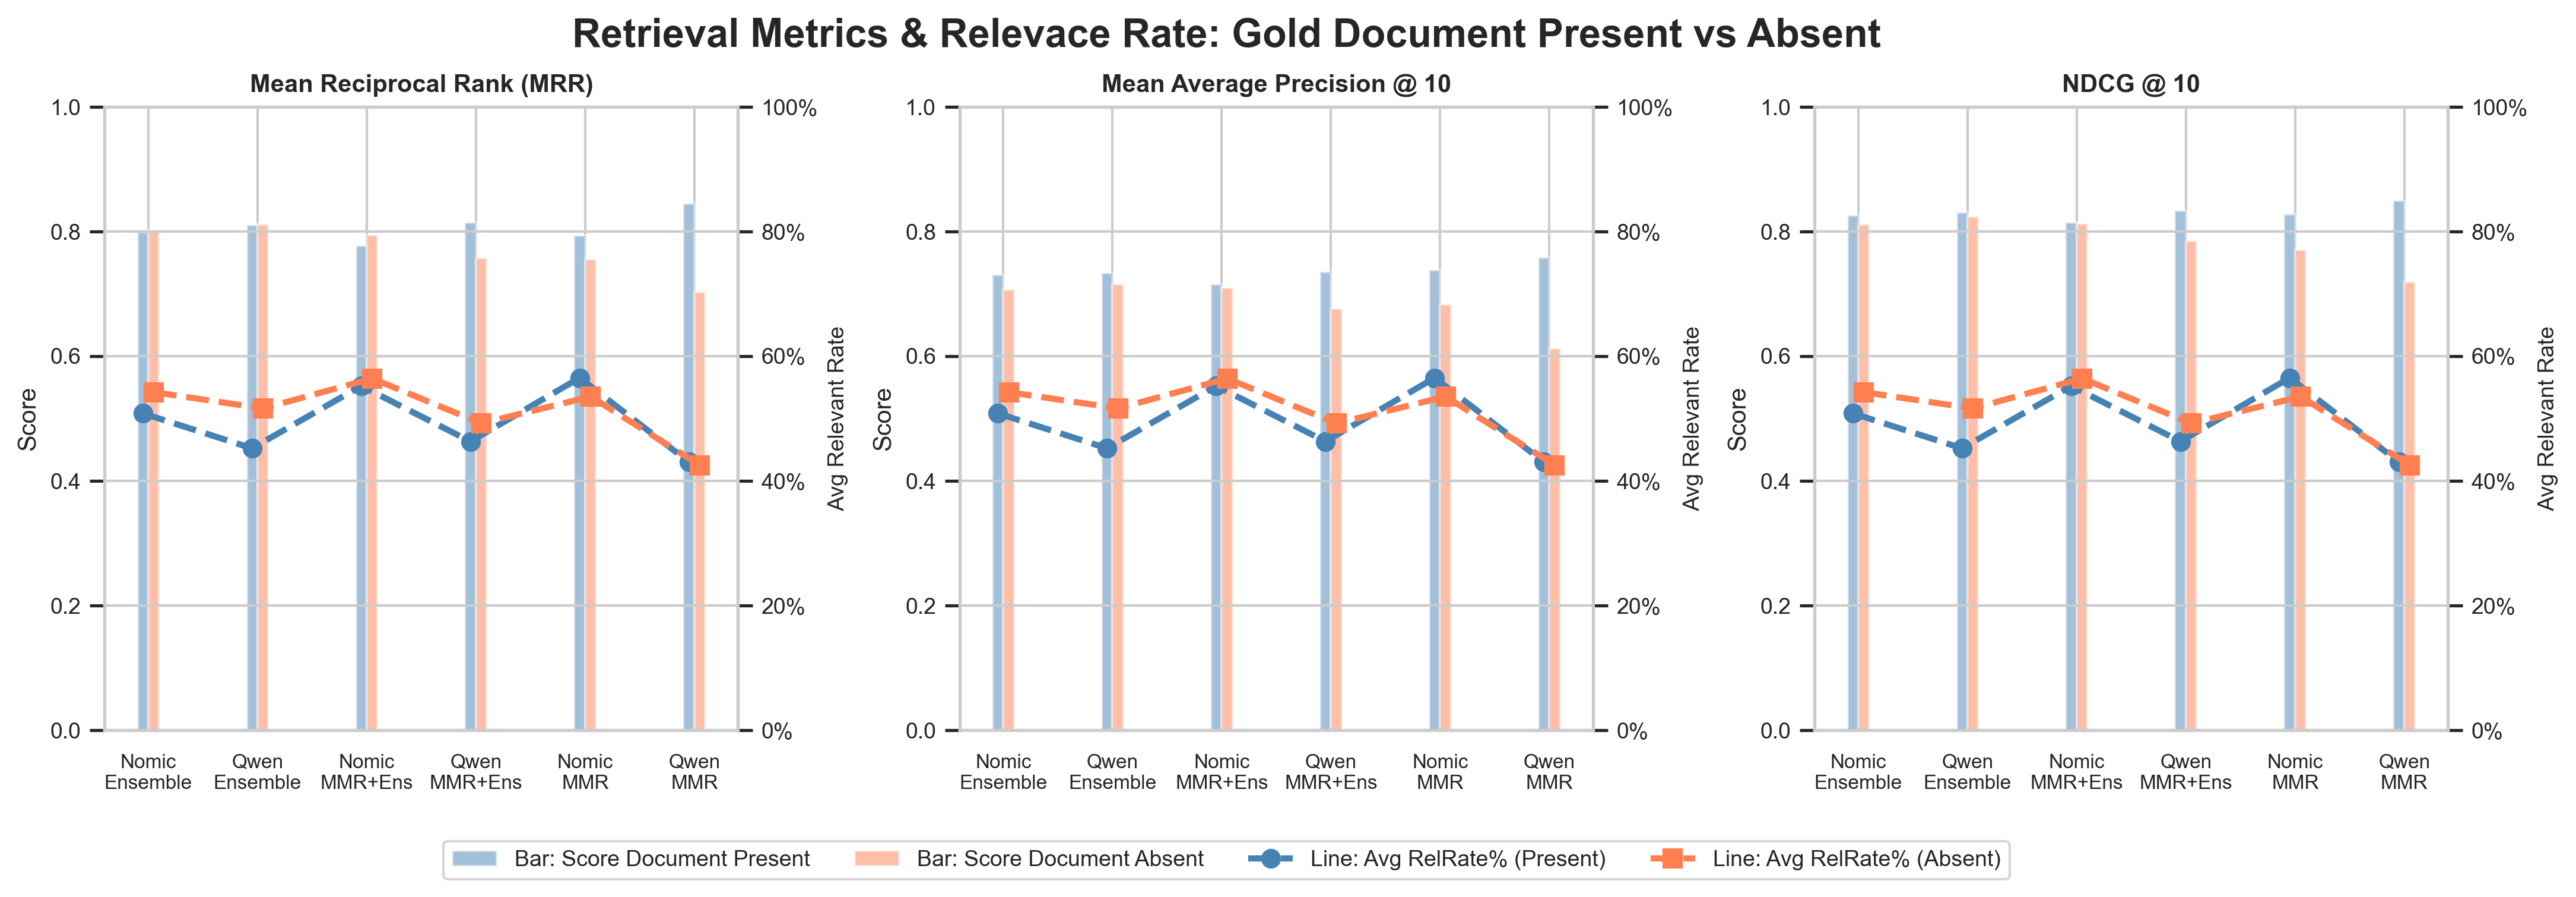

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

metrics = ['mrr', 'map@10', 'ndcg@10']
colors  = ['steelblue', 'coral']

metric_titles = {
    'mrr': 'Mean Reciprocal Rank (MRR)',
    'map@10': 'Mean Average Precision @ 10',
    'ndcg@10': 'NDCG @ 10'
}

# -------------------------
# Data prep
# -------------------------
plot_df = final.copy()
plot_df = plot_df[~plot_df['dataset'].str.contains('QUERY', case=False)].reset_index(drop=True)

def clean_dataset_name(raw_name):
    name_lower = str(raw_name).lower()
    if 'nomic' in name_lower:
        embedder = 'Nomic'
    elif 'qwen' in name_lower:
        embedder = 'Qwen'
    else:
        embedder = 'Unknown'
    if 'mmr+ensemble' in name_lower:
        retriever = 'MMR+Ens'
    elif 'ensemble' in name_lower:
        retriever = 'Ensemble'
    elif 'mmr' in name_lower:
        retriever = 'MMR'
    else:
        retriever = 'Standard'
    if embedder != 'Unknown' or retriever != 'Standard':
        return f"{embedder}\n{retriever}"
    return raw_name

plot_df['dataset'] = plot_df['dataset'].apply(clean_dataset_name)

for col in [f'{m}{s}' for m in metrics for s in ['_present', '_absent']]:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

for col in ['avg_relevant_present', 'avg_relevant_absent']:
    plot_df[col] = (plot_df[col]
                    .replace('N/A', np.nan)
                    .str.rstrip('%')
                    .astype(float) / 100)

datasets = plot_df['dataset'].tolist()
n = len(datasets)

x     = np.arange(n) * 3.0
width = 0.30

# -------------------------
# Build legend handles once
# -------------------------
legend_handles = [
    Patch(facecolor='steelblue', alpha=0.5, label='Bar: Score Document Present'),
    Patch(facecolor='coral',     alpha=0.5, label='Bar: Score Document Absent'),
    Line2D([0], [0], color='steelblue', marker='o', linestyle='--',
           linewidth=2.5, markersize=7,  label='Line: Avg RelRate% (Present)'),
    Line2D([0], [0], color='coral',     marker='s', linestyle='--',
           linewidth=2.5, markersize=7,  label='Line: Avg RelRate% (Absent)'),
]

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 5), dpi=300, sharey=False)

for ax, metric in zip(axes, metrics):

    ax.bar(x - width/2, plot_df[f'{metric}_present'], width,
           color=colors[0], alpha=0.5)
    ax.bar(x + width/2, plot_df[f'{metric}_absent'],  width,
           color=colors[1], alpha=0.5)

    ax.set_title(metric_titles[metric], fontsize=10, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=0, ha='center', fontsize=8)

    ax.set_ylabel('Score', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_ylim(0, 1)
    ax.set_xlim(x[0] - 1.2, x[-1] + 1.2)
    ax.grid(axis='y', alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(x - width/2, plot_df['avg_relevant_present'],
             color='steelblue', marker='o', linestyle='--',
             linewidth=2.5, markersize=7, alpha=1.0)
    ax2.plot(x + width/2, plot_df['avg_relevant_absent'],
             color='coral', marker='s', linestyle='--',
             linewidth=2.5, markersize=7, alpha=1.0)
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('Avg Relevant Rate', fontsize=9)
    ax2.tick_params(axis='y', labelsize=9)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

    # ✅ No per-subplot legend anymore

plt.suptitle('Retrieval Metrics & Relevace Rate: Gold Document Present vs Absent',
             fontsize=16, fontweight='bold')

# ✅ Single centered legend below all subplots
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=4,               # all 4 items in one row
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, 0.0),  # centered horizontally, anchored at figure bottom
)

plt.subplots_adjust(
    top=0.88,
    bottom=0.18,   # ✅ enough room for the legend below the axes
    left=0.05,
    right=0.99,
    wspace=0.35
)

#plt.savefig('metrics_present_vs_absent.png', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
import numpy as np
import pandas as pd
from rank_eval import Qrels, Run, evaluate

# ─────────────────────────────────────────────────────────────
# Settings
# ─────────────────────────────────────────────────────────────

N_BOOTSTRAP = 10000
BOOTSTRAP_SEED = 42


# ─────────────────────────────────────────────────────────────
# Core metric helpers (self-contained — no dependency on other cells)
# ─────────────────────────────────────────────────────────────

def compute_rank_eval(subset):
    """MRR / MAP@10 / NDCG@10 averaged over queries."""
    qrels_dict, run_dict = {}, {}
    for query_key, qgroup in subset.groupby('query_key'):
        relevant_docs = qgroup[qgroup['relevance'] == 'relevant']['doc_file'].tolist()
        qrels_dict[query_key] = (
            {doc: 1 for doc in relevant_docs} if relevant_docs
            else {qgroup['gold_file'].iloc[0]: 1}
        )
        run_dict[query_key] = {
            row['doc_file']: float(row['cross_encoder_score'])
            for _, row in qgroup.iterrows()
            if pd.notna(row['cross_encoder_score'])
        }
    qrels = Qrels.from_dict(qrels_dict)
    run   = Run.from_dict(run_dict)
    return evaluate(qrels, run, ["mrr", "map@10", "ndcg@10"])


def get_per_query_scores(subset):
    """Per-query mrr / map@10 / ndcg@10 arrays (no averaging)."""
    qrels_dict, run_dict = {}, {}
    for query_key, qgroup in subset.groupby('query_key'):
        relevant_docs = qgroup[qgroup['relevance'] == 'relevant']['doc_file'].tolist()
        qrels_dict[query_key] = (
            {doc: 1 for doc in relevant_docs} if relevant_docs
            else {qgroup['gold_file'].iloc[0]: 1}
        )
        run_dict[query_key] = {
            row['doc_file']: float(row['cross_encoder_score'])
            for _, row in qgroup.iterrows()
            if pd.notna(row['cross_encoder_score'])
        }
    qrels = Qrels.from_dict(qrels_dict)
    run   = Run.from_dict(run_dict)
    scores = evaluate(qrels, run, ["mrr", "map@10", "ndcg@10"], return_mean=False)

    return (
        np.asarray(scores['mrr'],     dtype=float),
        np.asarray(scores['map@10'],  dtype=float),
        np.asarray(scores['ndcg@10'], dtype=float),
    )


def compute_hits(subset):
    """Hit@1/3/5/10 based on where the gold doc ranks by cross_encoder_score."""
    rows = []
    for query_key, qgroup in subset.groupby('query_key'):
        gold  = qgroup['gold_file'].iloc[0]
        files = qgroup.sort_values('cross_encoder_score', ascending=False)['doc_file'].tolist()
        rank  = next((i for i, f in enumerate(files, 1) if f == gold), None)
        rows.append({
            'query_key': query_key,
            'gold_file': gold,
            'hit@1':  rank is not None and rank <= 1,
            'hit@3':  rank is not None and rank <= 3,
            'hit@5':  rank is not None and rank <= 5,
            'hit@10': rank is not None and rank <= 10,
        })
    hits = pd.DataFrame(rows)
    return {
        'queries':   len(hits),
        'hit_at_1':  hits['hit@1'].mean(),
        'hit_at_3':  hits['hit@3'].mean(),
        'hit_at_5':  hits['hit@5'].mean(),
        'hit_at_10': hits['hit@10'].mean(),
        '_hits_df':  hits,
    }


def compute_precision_recall_at_k(subset, k_values=[1, 3, 5, 10]):
    """Per-query precision@k / recall@k, deduplicated to document level."""
    results = {f'p@{k}': [] for k in k_values}
    results.update({f'r@{k}': [] for k in k_values})

    for query_key, qgroup in subset.groupby('query_key'):
        relevant_docs = set(
            qgroup.groupby('doc_file')['relevance']
            .apply(lambda x: (x == 'relevant').any())
            .loc[lambda x: x].index
        )
        if not relevant_docs:
            relevant_docs = {qgroup['gold_file'].iloc[0]}

        ranked = (qgroup
            .sort_values('cross_encoder_score', ascending=False)
            .drop_duplicates(subset='doc_file', keep='first')
            ['doc_file'].tolist())

        n_relevant = len(relevant_docs)

        for k in k_values:
            top_k              = set(ranked[:k])
            retrieved_relevant = len(top_k & relevant_docs)
            results[f'p@{k}'].append(retrieved_relevant / k)
            results[f'r@{k}'].append(retrieved_relevant / n_relevant if n_relevant > 0 else 0.0)

    return {key: np.array(vals, dtype=float) for key, vals in results.items()}


def avg_rel_rate(subset):
    doc_relevance = (subset
        .groupby(['query_key', 'doc_file'])['relevance']
        .apply(lambda x: 'relevant' if (x == 'relevant').any() else 'not relevant')
        .reset_index())
    return (doc_relevance
        .groupby('query_key')['relevance']
        .apply(lambda x: (x == 'relevant').mean())
        .mean())


# ─────────────────────────────────────────────────────────────
# Fast bootstrap over pre-computed per-query values
# ─────────────────────────────────────────────────────────────

def bootstrap_from_values(values, n_bootstrap=N_BOOTSTRAP, seed=BOOTSTRAP_SEED):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    n = len(values)
    if n <= 1:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_bootstrap, n))
    boot_means = values[idx].mean(axis=1)

    return values.mean(), np.percentile(boot_means, 2.5), np.percentile(boot_means, 97.5)


# ─────────────────────────────────────────────────────────────
# Build the CI table
# ─────────────────────────────────────────────────────────────

first_model  = df['model'].iloc[0]
df_one_model = df[df['model'] == first_model].copy()

ci_rows = []

for dataset_name, group in df_one_model.groupby("dataset"):

    n_queries = group["query_key"].nunique()
    ci_row = {"dataset": dataset_name, "queries": n_queries}

    mrr_vals, map_vals, ndcg_vals = get_per_query_scores(group)
    hits_all = compute_hits(group)
    hits_df  = hits_all["_hits_df"]
    pr_vals  = compute_precision_recall_at_k(group)

    per_query_rel = (
        group.groupby(["query_key", "doc_file"])["relevance"]
        .apply(lambda x: "relevant" if (x == "relevant").any() else "not relevant")
        .reset_index()
        .groupby("query_key")["relevance"]
        .apply(lambda x: (x == "relevant").mean())
        .values
    )

    for name, vals in [("mrr", mrr_vals), ("map@10", map_vals), ("ndcg@10", ndcg_vals)]:
        mean, low, high = bootstrap_from_values(vals)
        ci_row[name], ci_row[f"{name}_low"], ci_row[f"{name}_high"] = mean, low, high

    for k in [1, 3, 5, 10]:
        mean, low, high = bootstrap_from_values(hits_df[f"hit@{k}"].astype(float).values)
        ci_row[f"hit_at_{k}"], ci_row[f"hit_at_{k}_low"], ci_row[f"hit_at_{k}_high"] = mean, low, high

    for k in [1, 3, 5, 10]:
        for prefix in ["p", "r"]:
            key = f"{prefix}@{k}"
            mean, low, high = bootstrap_from_values(pr_vals[key])
            ci_row[key], ci_row[f"{key}_low"], ci_row[f"{key}_high"] = mean, low, high

    mean, low, high = bootstrap_from_values(per_query_rel)
    ci_row["avg_relevant_rate"], ci_row["avg_relevant_rate_low"], ci_row["avg_relevant_rate_high"] = mean, low, high

    ci_rows.append(ci_row)

ci_df = pd.DataFrame(ci_rows)
print("\nBootstrap CI table created:")
print(ci_df.head())


Bootstrap CI table created:
                             dataset  queries       mrr   mrr_low  mrr_high  \
0      ensemble__nomic-chatfaq__FULL     1185  0.799122  0.782014  0.816244   
1     ensemble__nomic-chatfaq__QUERY      182  0.789063  0.746113  0.830913   
2       ensemble__qwen-chatfaq__FULL     1185  0.810782  0.794240  0.827311   
3      ensemble__qwen-chatfaq__QUERY      182  0.829487  0.787546  0.870330   
4  mmr+ensemble__nomic-chatfaq__FULL     1185  0.780029  0.762948  0.797569   

     map@10  map@10_low  map@10_high   ndcg@10  ndcg@10_low  ...  r@5_high  \
0  0.725934    0.712015     0.740215  0.822667     0.811659  ...  0.878080   
1  0.713386    0.677901     0.748298  0.815050     0.787906  ...  0.906293   
2  0.729392    0.715755     0.742978  0.828853     0.818400  ...  0.870085   
3  0.745399    0.710259     0.780481  0.841035     0.814734  ...  0.899298   
4  0.714051    0.699866     0.728258  0.813516     0.802424  ...  0.869353   

       p@10  p@10_low  p@10

In [50]:
import numpy as np
import pandas as pd


# ─────────────────────────────────────────────────────────────
# 1. METRICS
# ─────────────────────────────────────────────────────────────

METRICS = ["p@1", "p@3", "p@5", "r@1", "r@5"]


# ─────────────────────────────────────────────────────────────
# 2. NORMALIZE STRATEGY LABELS
# ─────────────────────────────────────────────────────────────

def normalize_dataset(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    if "ensemble" in x and "mmr" in x:
        return "Hybrid"

    if "ensemble" in x:
        return "Ensemble"

    if "mmr" in x:
        return "MMR"

    return np.nan


# ─────────────────────────────────────────────────────────────
# 3. AGGREGATE TABLE (BOOTSTRAP-CONSISTENT)
# ─────────────────────────────────────────────────────────────

def aggregate_pr_table(ci_df):

    df = ci_df.copy()
    df["Strategy"] = df["dataset"].apply(normalize_dataset)

    rows = []

    for strategy, g in df.groupby("Strategy"):

        if pd.isna(strategy):
            continue

        row = {"Strategy": strategy}

        for m in METRICS:

            mean_col = m
            low_col  = f"{m}_low"
            high_col = f"{m}_high"

            if mean_col not in g.columns:
                row[m] = "N/A"
                continue

            mean_vals = pd.to_numeric(g[mean_col], errors="coerce").dropna()

            if len(mean_vals) == 0:
                row[m] = "N/A"
                continue

            # Prefer CI bounds if available
            if low_col in g.columns and high_col in g.columns:

                low_vals  = pd.to_numeric(g[low_col], errors="coerce").dropna()
                high_vals = pd.to_numeric(g[high_col], errors="coerce").dropna()

                if len(low_vals) > 0 and len(high_vals) > 0:
                    row[m] = f"{low_vals.min():.3f}–{high_vals.max():.3f}"
                else:
                    row[m] = f"{mean_vals.min():.3f}–{mean_vals.max():.3f}"

            else:
                row[m] = f"{mean_vals.min():.3f}–{mean_vals.max():.3f}"

        rows.append(row)

    return pd.DataFrame(rows)


# ─────────────────────────────────────────────────────────────
# 4. ORDER LIKE PAPER
# ─────────────────────────────────────────────────────────────

def order_table(df):

    order = ["Ensemble", "MMR", "Hybrid"]

    df = df[df["Strategy"].notna()].copy()
    df = df[df["Strategy"].isin(order)].copy()

    df["Strategy"] = pd.Categorical(df["Strategy"], categories=order, ordered=True)

    return df.sort_values("Strategy").reset_index(drop=True)


# ─────────────────────────────────────────────────────────────
# 5. PRINT CLEAN TABLE
# ─────────────────────────────────────────────────────────────

def print_table(df):

    print("\n=== PRECISION / RECALL TABLE ===\n")

    if df.empty:
        print("❌ Empty table")
        return

    for _, r in df.iterrows():

        print(
            f"{r['Strategy']:<10s}  "
            f"{r['p@1']:>15s}  "
            f"{r['p@3']:>15s}  "
            f"{r['p@5']:>15s}  "
            f"{r['r@1']:>15s}  "
            f"{r['r@5']:>15s}"
        )


# ─────────────────────────────────────────────────────────────
# 6. RUN
# ─────────────────────────────────────────────────────────────

table = aggregate_pr_table(ci_df)
table = order_table(table)

print_table(table)

print("\n=== DATAFRAME ===\n")
print(table)


=== PRECISION / RECALL TABLE ===

Ensemble        0.791–0.929      0.581–0.661      0.466–0.536      0.347–0.445      0.845–0.906
MMR             0.720–0.940      0.507–0.689      0.399–0.543      0.339–0.468      0.785–0.916
Hybrid          0.824–0.929      0.571–0.679      0.442–0.546      0.351–0.473      0.840–0.919

=== DATAFRAME ===

   Strategy          p@1          p@3          p@5          r@1          r@5
0  Ensemble  0.791–0.929  0.581–0.661  0.466–0.536  0.347–0.445  0.845–0.906
1       MMR  0.720–0.940  0.507–0.689  0.399–0.543  0.339–0.468  0.785–0.916
2    Hybrid  0.824–0.929  0.571–0.679  0.442–0.546  0.351–0.473  0.840–0.919


                             dataset       p@1   p@1_low  p@1_high
0      ensemble__nomic-chatfaq__FULL  0.871730  0.853165  0.890295
1       ensemble__qwen-chatfaq__FULL  0.881013  0.862447  0.899578
2  mmr+ensemble__nomic-chatfaq__FULL  0.888608  0.870042  0.906329
3   mmr+ensemble__qwen-chatfaq__FULL  0.884388  0.866667  0.902110
4           mmr__nomic-chatfaq__FULL  0.886920  0.868354  0.904641
5            mmr__qwen-chatfaq__FULL  0.858228  0.838819  0.877637


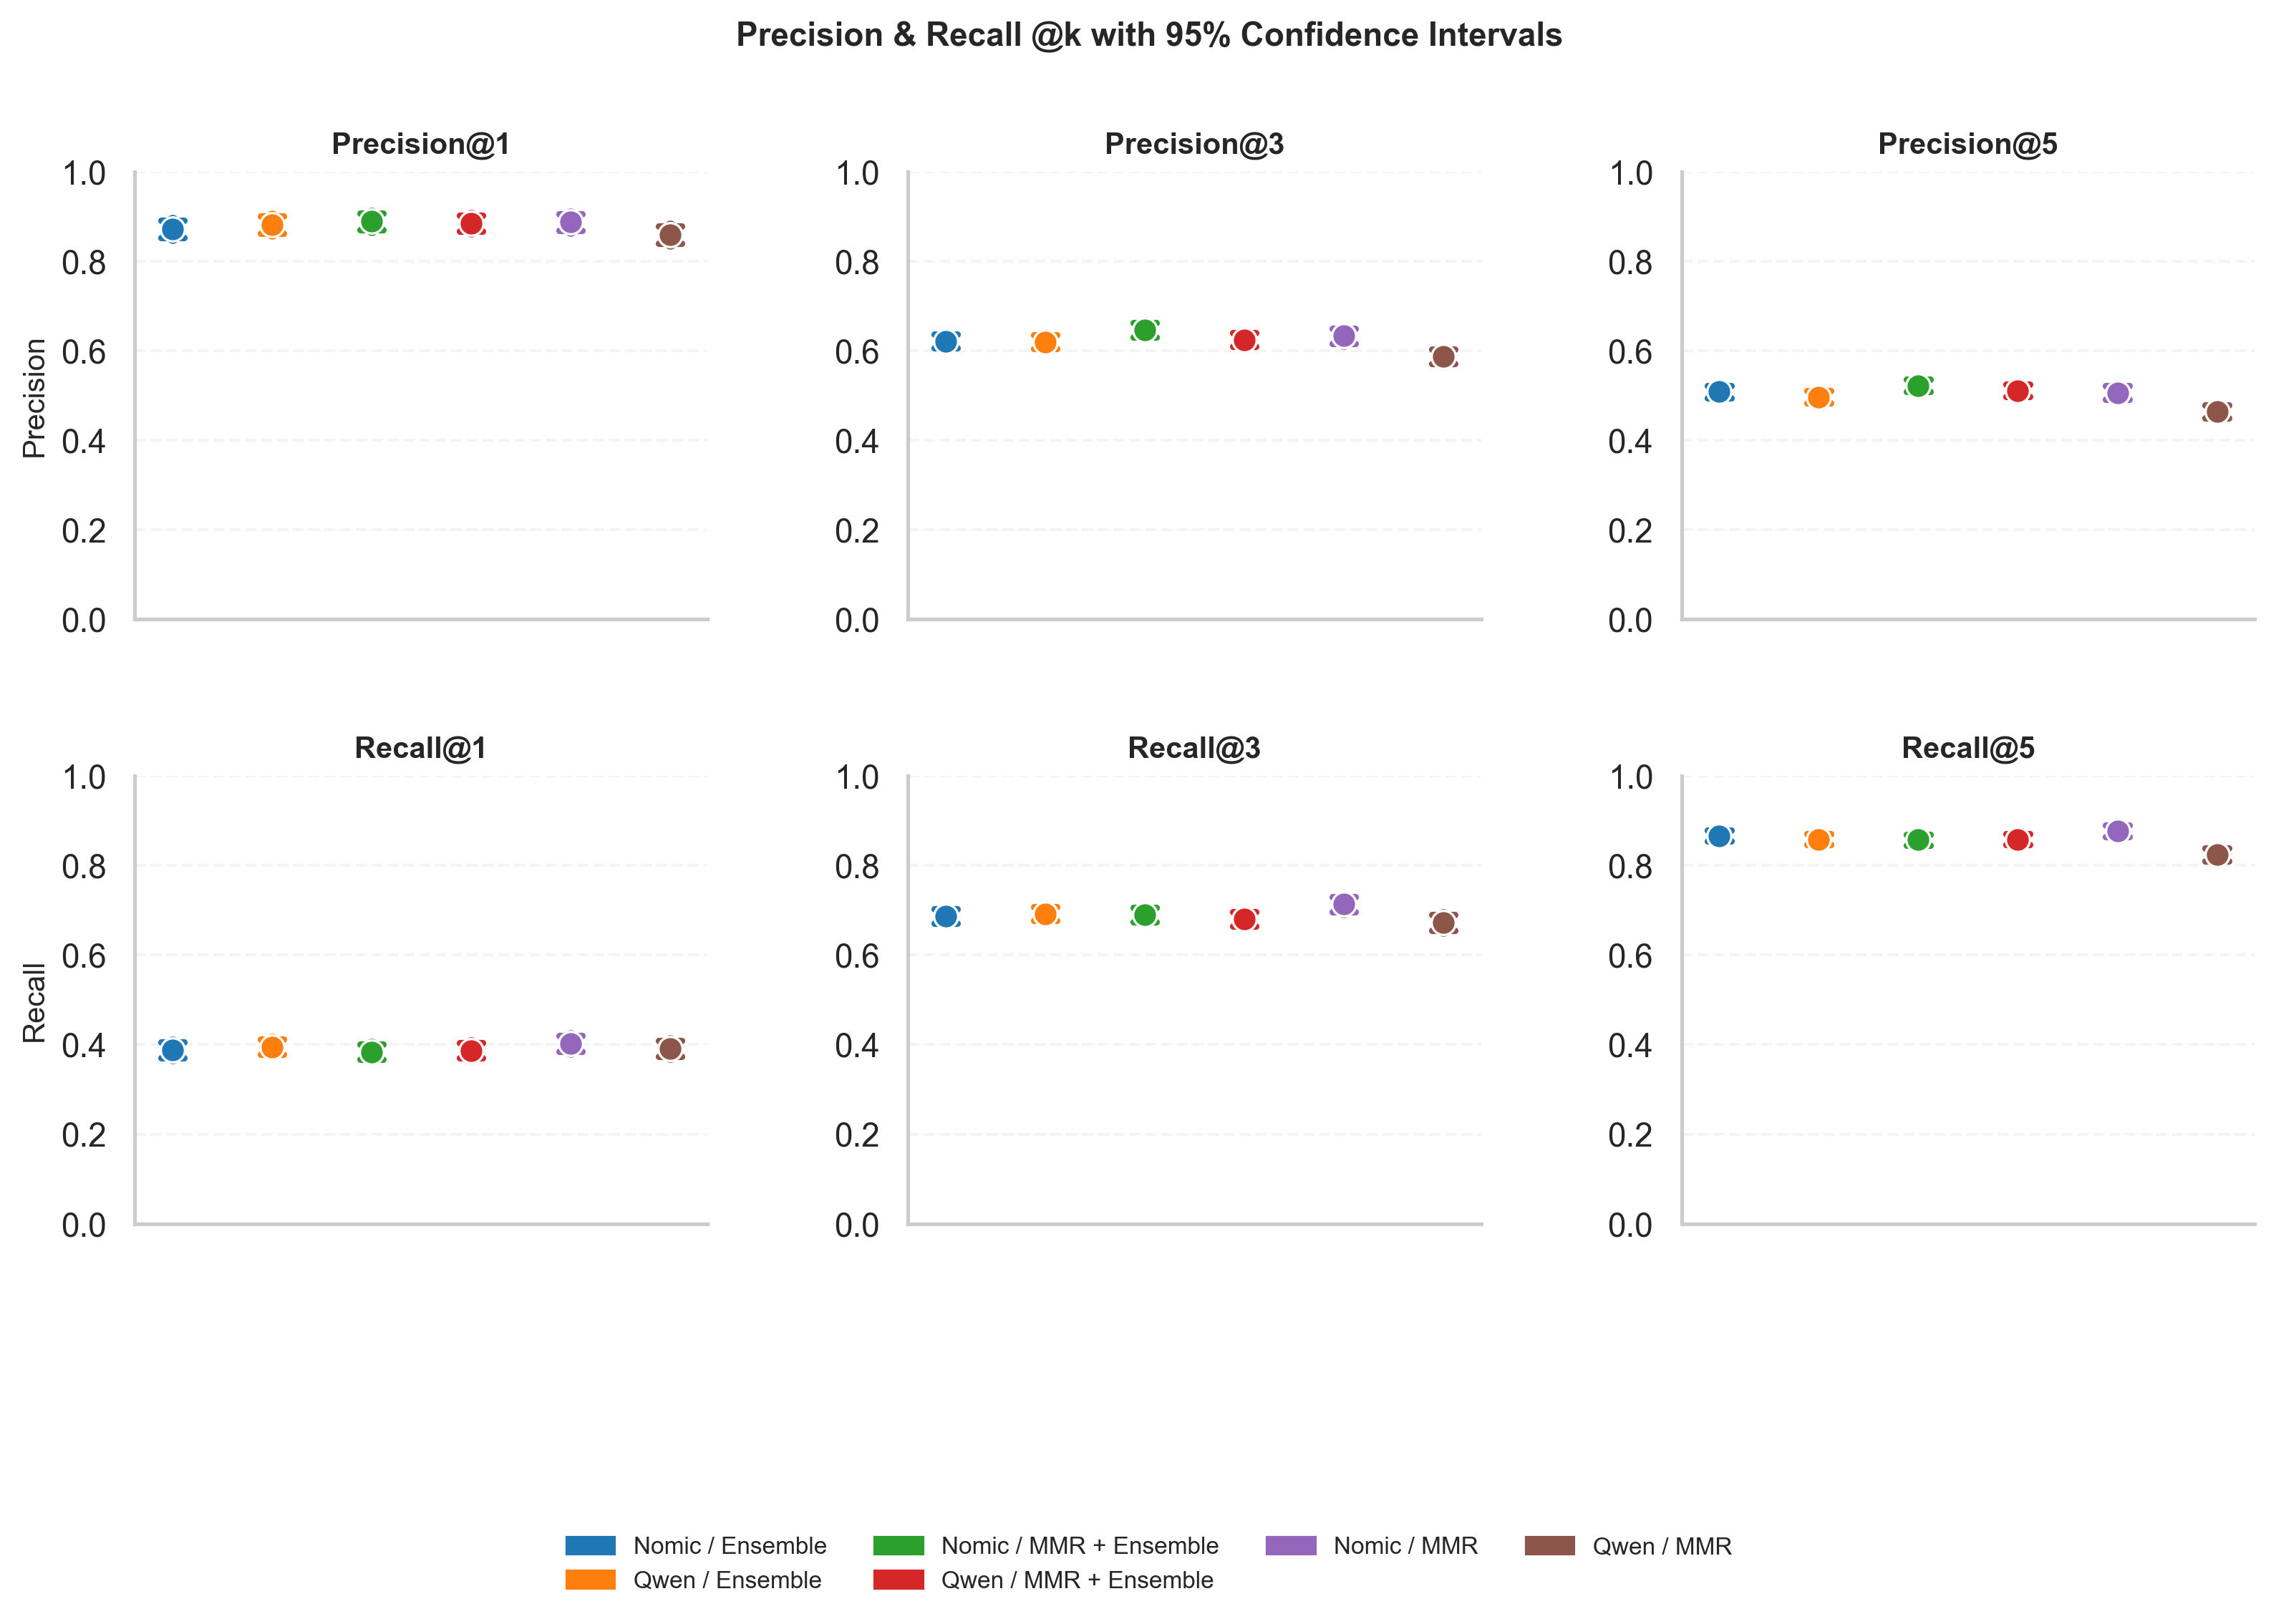

In [51]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd


# ============================================================
# Prepare dataframe
# NO aggregation: keep every retriever configuration
# ============================================================

plot_df = (
    ci_df[
        ~ci_df['dataset']
        .astype(str)
        .str.contains('QUERY', case=False)
    ]
    .copy()
    .reset_index(drop=True)
)


def clean_dataset_name(raw_name):
    name_lower = str(raw_name).lower()

    if 'nomic' in name_lower:
        embedder = 'Nomic'
    elif 'qwen' in name_lower:
        embedder = 'Qwen'
    else:
        embedder = 'Unknown'

    if 'mmr+ensemble' in name_lower or 'mmr + ensemble' in name_lower:
        retriever = 'MMR + Ensemble'
    elif 'ensemble' in name_lower:
        retriever = 'Ensemble'
    elif 'mmr' in name_lower:
        retriever = 'MMR'
    else:
        retriever = 'Standard'

    if embedder != 'Unknown' or retriever != 'Standard':
        return f"{embedder} / {retriever}"

    return raw_name


# Only rename labels, do NOT modify metric values
datasets = [
    clean_dataset_name(d)
    for d in plot_df['dataset']
]

n = len(datasets)

print(plot_df[['dataset', 'p@1', 'p@1_low', 'p@1_high']])


# ============================================================
# Plot
# ============================================================

x_coords = np.arange(n) * 2.4

colors = [plt.cm.tab10(i % 10) for i in range(n)]

k_values = [1, 3, 5]


fig, axes = plt.subplots(
    2,
    len(k_values),
    figsize=(10.5, 7.0),
    dpi=300
)


for row_idx, metric_prefix in enumerate(['p', 'r']):

    for col_idx, k in enumerate(k_values):

        ax = axes[row_idx][col_idx]

        col_mean = f'{metric_prefix}@{k}'
        col_low  = f'{metric_prefix}@{k}_low'
        col_high = f'{metric_prefix}@{k}_high'


        for i, (_, row) in enumerate(plot_df.iterrows()):

            mean = row[col_mean]
            low  = row[col_low]
            high = row[col_high]


            if any(pd.isna(v) for v in [mean, low, high]):
                continue


            color = colors[i]
            x = x_coords[i]

            cap = 0.28


            # Confidence interval band
            ax.fill_between(
                [x - 0.12, x + 0.12],
                low,
                high,
                color=color,
                alpha=0.25,
                zorder=0
            )


            # Confidence interval line
            ax.plot(
                [x, x],
                [low, high],
                color=color,
                linewidth=4,
                zorder=2
            )


            # Caps
            ax.plot(
                [x-cap, x+cap],
                [low, low],
                color=color,
                linewidth=2.2,
                zorder=2
            )

            ax.plot(
                [x-cap, x+cap],
                [high, high],
                color=color,
                linewidth=2.2,
                zorder=2
            )


            # Mean
            ax.scatter(
                x,
                mean,
                color=color,
                s=65,
                edgecolors='white',
                linewidths=0.8,
                zorder=3
            )


        ax.set_title(
            f"{'Precision' if metric_prefix=='p' else 'Recall'}@{k}",
            fontsize=10,
            fontweight='bold'
        )

        ax.set_ylim(0, 1)
        ax.set_xticks([])

        ax.grid(
            axis='y',
            linestyle='--',
            alpha=0.2
        )

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)


        if col_idx == 0:
            ax.set_ylabel(
                'Precision' if metric_prefix == 'p' else 'Recall',
                fontsize=10
            )


# ============================================================
# Legend
# ============================================================

handles = [
    mpatches.Patch(
        color=colors[i],
        label=datasets[i]
    )
    for i in range(n)
]


fig.legend(
    handles=handles,
    loc='lower center',
    ncol=min(n,4),
    fontsize=8,
    frameon=False,
    bbox_to_anchor=(0.5,-0.08)
)


plt.suptitle(
    'Precision & Recall @k with 95% Confidence Intervals',
    fontsize=11,
    fontweight='bold'
)


plt.subplots_adjust(
    top=0.88,
    bottom=0.18,
    left=0.05,
    right=0.99,
    wspace=0.35,
    hspace=0.35
)


plt.show()

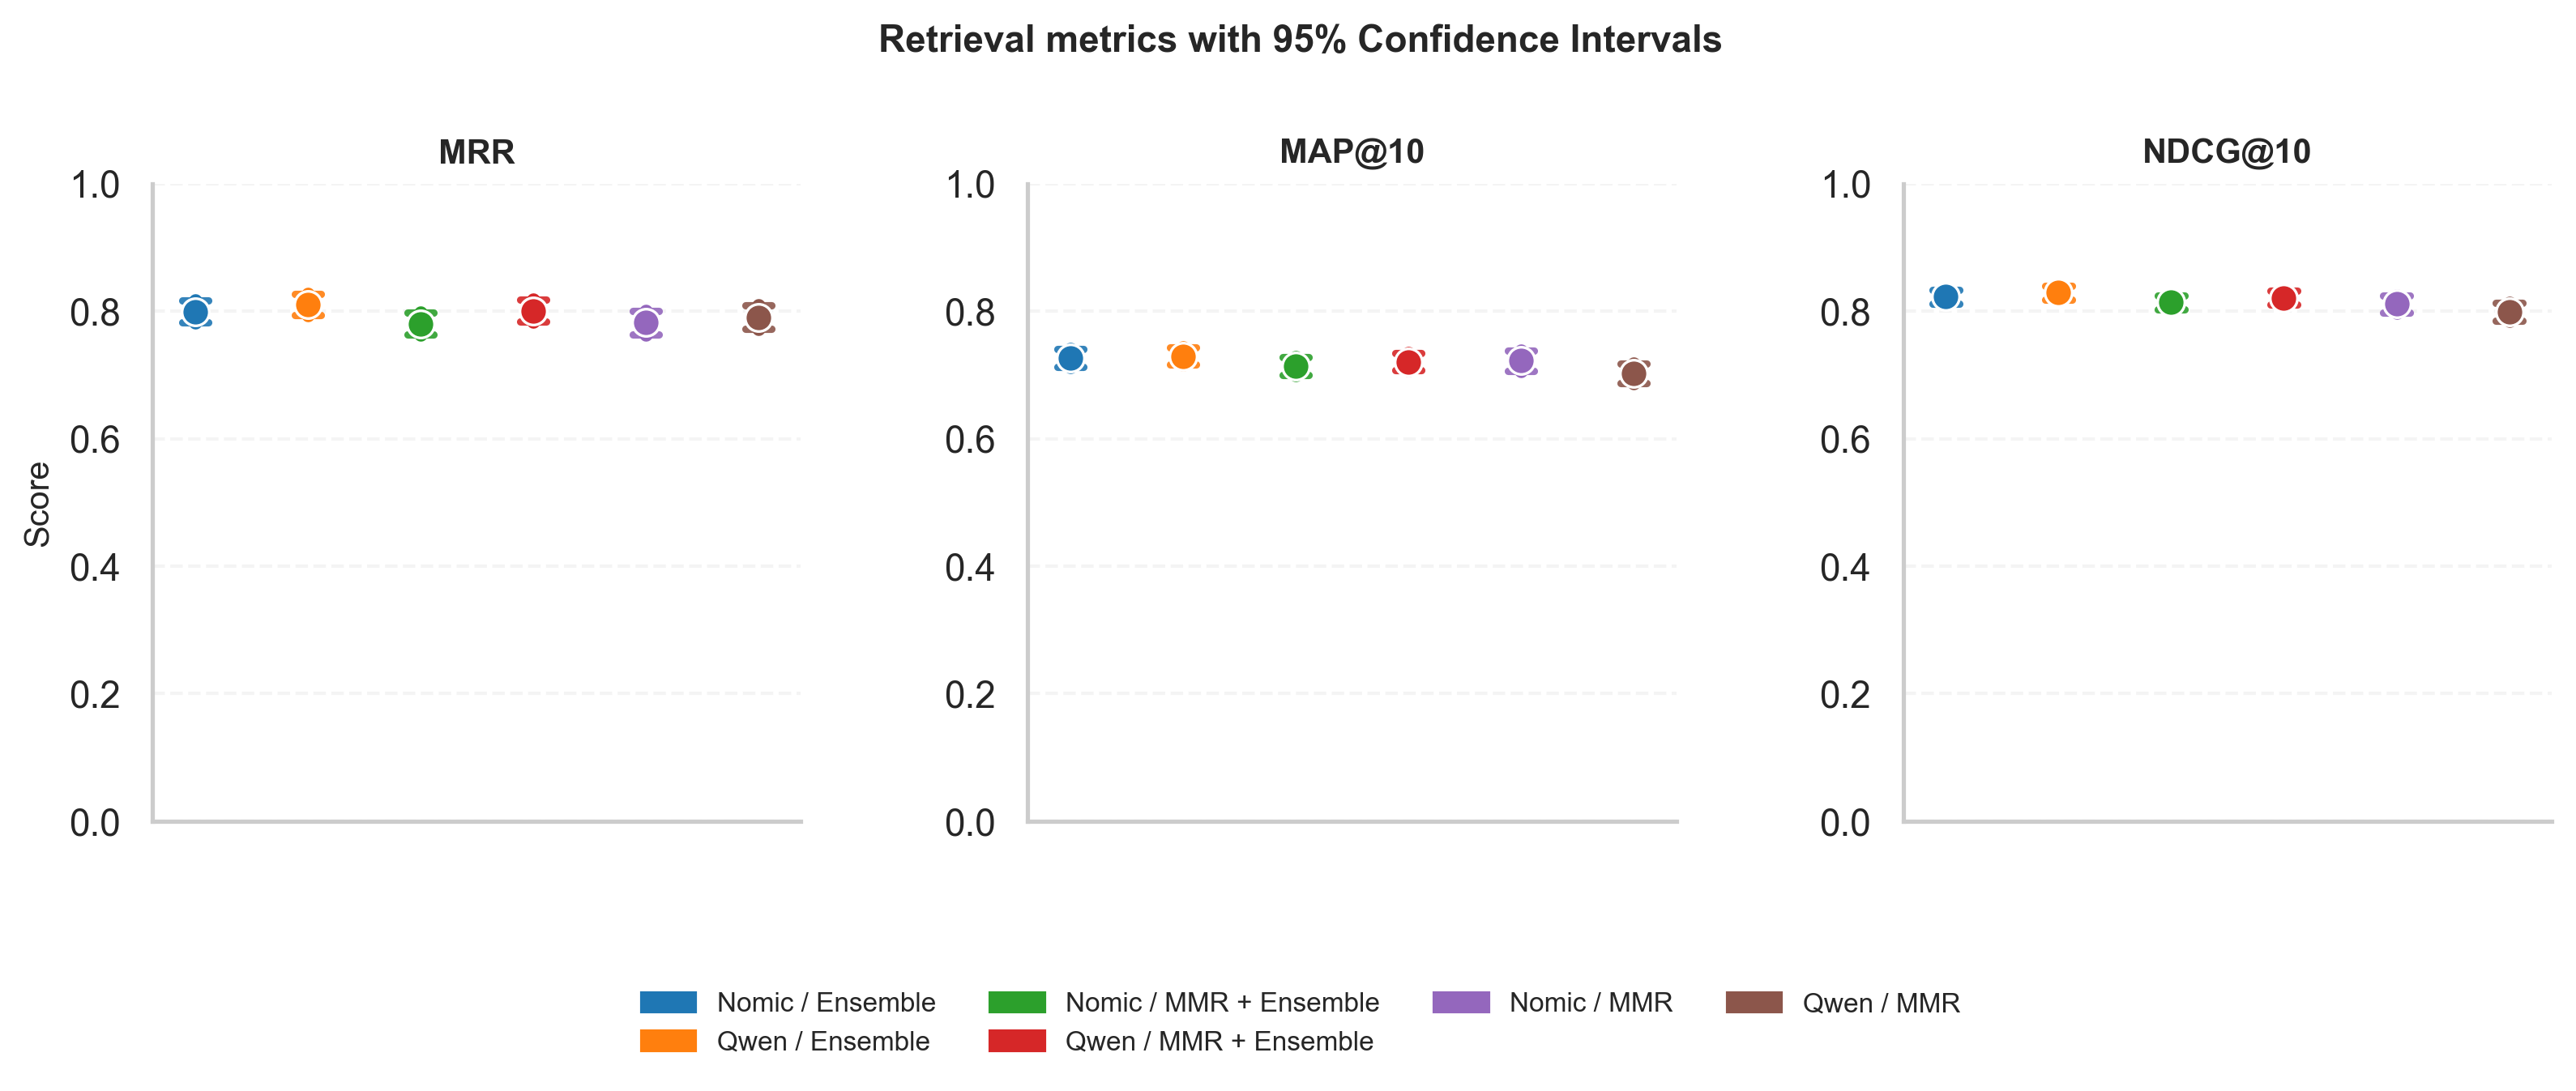

In [52]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

metrics = {
    'MRR':     ('mrr',       'mrr_low',       'mrr_high'),
    'MAP@10':  ('map@10',    'map@10_low',    'map@10_high'),
    'NDCG@10': ('ndcg@10',   'ndcg@10_low',   'ndcg@10_high'),
}

plot_df = ci_df[~ci_df['dataset'].str.contains('QUERY', case=False)].reset_index(drop=True)

def clean_dataset_name(raw_name):
    name_lower = str(raw_name).lower()

    if 'nomic' in name_lower:
        embedder = 'Nomic'
    elif 'qwen' in name_lower:
        embedder = 'Qwen'
    else:
        embedder = 'Unknown'

    if 'mmr+ensemble' in name_lower:
        retriever = 'MMR + Ensemble'
    elif 'ensemble' in name_lower:
        retriever = 'Ensemble'
    elif 'mmr' in name_lower:
        retriever = 'MMR'
    else:
        retriever = 'Standard'

    if embedder != 'Unknown' or retriever != 'Standard':
        return f"{embedder} / {retriever}"
    return raw_name


datasets = [clean_dataset_name(d) for d in plot_df['dataset'].tolist()]
n = len(datasets)

# 🔥 MUCH MORE SPACE BETWEEN POINTS
x_coords = np.arange(n) * 2.4

colors = [plt.cm.tab10(i % 10) for i in range(n)]

# 🔥 WIDER FIGURE (KEY FIX)
fig, axes = plt.subplots(
    1, len(metrics),
    figsize=(10.5, 4.1),   # <<< IMPORTANT CHANGE
    dpi=300
)

for ax, (metric_label, (col_mean, col_low, col_high)) in zip(axes, metrics.items()):

    for i, (_, row) in enumerate(plot_df.iterrows()):

        mean = row[col_mean]
        low  = row[col_low]
        high = row[col_high]

        if any(pd.isna(v) for v in [mean, low, high]):
            continue

        color = colors[i]
        x = x_coords[i]

        # 🔥 STRONGER + MORE VISIBLE CI

        # CI BAND (stronger visibility)
        ax.fill_between(
            [x - 0.12, x + 0.12],
            low,
            high,
            color=color,
            alpha=0.25,
            zorder=0
        )

        # CI LINE (thicker = clearer)
        ax.plot(
            [x, x],
            [low, high],
            color=color,
            linewidth=4.0,
            alpha=1.0,
            solid_capstyle='round',
            zorder=2
        )

        # CAPS
        cap = 0.28
        ax.plot([x - cap, x + cap], [low, low],
                color=color, linewidth=2.2, alpha=0.9, zorder=2)

        ax.plot([x - cap, x + cap], [high, high],
                color=color, linewidth=2.2, alpha=0.9, zorder=2)

        # MEAN
        ax.scatter(
            x, mean,
            color=color,
            s=65,
            edgecolors='white',
            linewidths=0.8,
            zorder=3
        )

    # ---------------------------
    # AXES
    # ---------------------------
    ax.set_title(metric_label, fontsize=10, fontweight='bold')

    ax.set_xticks([])
    ax.set_xticklabels([])

    ax.set_ylim(0, 1)

    ax.grid(axis='y', linestyle='--', alpha=0.2)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if ax == axes[0]:
        ax.set_ylabel('Score', fontsize=10)

# ---------------------------
# LEGEND
# ---------------------------
handles = [
    mpatches.Patch(color=colors[i], label=datasets[i])
    for i in range(n)
]

fig.legend(
    handles=handles,
    loc='lower center',
    ncol=min(n, 4),
    fontsize=8,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08)
)

plt.suptitle(
    'Retrieval metrics with 95% Confidence Intervals',
    fontsize=11, fontweight='bold'
)

# ---------------------------
# LAYOUT (more breathing room)
# ---------------------------
plt.subplots_adjust(
    top=0.82,
    bottom=0.18,
    left=0.05,
    right=0.99,
    wspace=0.35
)

#plt.savefig("confidence_intervals_candle.png",dpi=300,bbox_inches='tight')

plt.show()